# Week 5 Analysis: Tell Me Something I Don't Know About r/place 2022

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
PARQUET_PATH = "../2022_place_canvas_history.parquet"

In [123]:
def hex_to_rgb(h: str):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def local(xmin, ymin, x, y):
    return x - xmin, y - ymin



def createGif(xmin: int, xmax: int, ymin: int , ymax: int, 
              df: pd.DataFrame, start_date = None, bins: int = 100, 
              file: str = None, 
              fps: int = 10, dt: int = 50):
    
    if (not file):
        file = f"rplace_{xmin}_{xmax}_{ymin}_{ymax}.gif"

    def paintCanvas(rows):
        for _, row in rows.iterrows():
            x2 = row['x2'] if not pd.isna(row.get('x2', np.nan)) else row['x1']
            y2 = row['y2'] if not pd.isna(row.get('y2', np.nan)) else row['y1']

            x_start = min(row['x1'], x2)
            x_end = max(row['x1'], x2)
            y_start = min(row['y1'], y2)
            y_end = max(row['y1'], y2)

            x_start, y_start = local(xmin, ymin, x_start, y_start)
            x_end, y_end = local(xmin, ymin, x_end, y_end)

            xs = np.arange(x_start, x_end + 1)
            ys = np.arange(y_start, y_end + 1)

            xs = xs[(xs >= 0) & (xs < canvas.shape[1])]
            ys = ys[(ys >= 0) & (ys < canvas.shape[0])]

            X, Y = np.meshgrid(xs, ys)
            canvas[Y.ravel(), X.ravel()] = row["rgb"]
    
    width = xmax - xmin + 50
    height = ymax - ymin + 50

    canvas = np.ones((height, width, 3))


    time_bin = bins

    df["rgb"] = df["pixel_color"].apply(hex_to_rgb)

    if (start_date):
        start_epoch = pd.Timestamp(start_date).timestamp()

        df_initial = df[df["timestamp_epoch"] < start_epoch]
        df_anim = df[df["timestamp_epoch"] >= start_epoch]
    else:
        df_initial = pd.DataFrame(df.columns)
        df_anim = df

    paintCanvas(df_initial)

    df_anim["frame"] = (df_anim["timestamp_epoch"] // time_bin)

    groups = list(df_anim.groupby("frame"))

    fig, ax = plt.subplots()
    img = ax.imshow(canvas)
    ax.axis("off")

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.set_position([0, 0, 1, 1])

    def update(frame):
        _, chunk = groups[frame]

        if chunk.empty:
            return [img]

        for _, row in chunk.iterrows():
            x2 = row['x2'] if not pd.isna(row.get('x2', np.nan)) else row['x1']
            y2 = row['y2'] if not pd.isna(row.get('y2', np.nan)) else row['y1']

            x_start = min(row['x1'], x2)
            x_end = max(row['x1'], x2)

            y_start = min(row['y1'], y2)
            y_end = max(row['y1'], y2)

            x_start, y_start = local(xmin, ymin, x_start, y_start)
            x_end, y_end = local(xmin, ymin, x_end, y_end)

            xs = np.arange(x_start, x_end + 1)
            ys = np.arange(y_start, y_end + 1)

            xs = xs[(xs >= 0) & (xs < canvas.shape[1])]
            ys = ys[(ys >= 0) & (ys < canvas.shape[0])]
            
            X, Y = np.meshgrid(xs, ys)

            xs_flat = X.ravel()
            ys_flat = Y.ravel()


            canvas[ys_flat, xs_flat] = row["rgb"]

        img.set_data(canvas)
        return [img]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(groups),
        interval=dt,
        blit=False
    )

    # fig.tight_layout(pad=3)
    ani.save(file, writer="pillow", fps=fps, savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0})
    # fig.savefig("last_frame.png")
    

# Osu Logo Placement

In [ ]:
centerx = 727   # RIP Cookiezi, pls come back
centery = 727
dr = 50

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 > {centerx - dr} AND x1 < {centerx + dr}) AND
        (y1 > {centery - dr} AND y1 < {centery + dr}) AND
    ORDER BY
        timestamp ASC
"""
df = duckdb.query(query).df()

createGif(centerx - dr, centerx + dr, centery - dr, centery + dr, df, file="osu.gif")


## r/StarWars Attack

C:\Users\Connor\AppData\Local\Temp\ipykernel_204480\1718351276.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anim["frame"] = (df_anim["timestamp_epoch"] // time_bin)


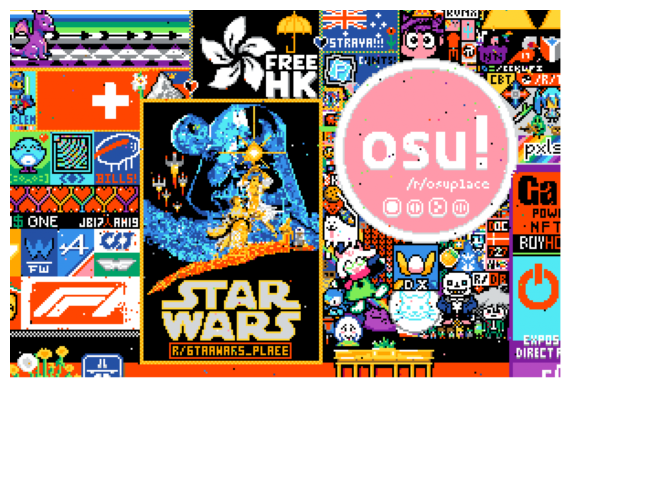

In [125]:
xmin, xmax = 500, 800
ymin, ymax = 650, 850

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 >= {xmin} AND x1 <= {xmax}) AND
        (y1 >= {ymin} AND y1 <= {ymax}) AND
        (timestamp < '2022-04-02 17:00:00')
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
createGif(xmin, xmax, ymin, ymax, df, start_date='2022-04-02 14:00:00', file="star_wars_attack.gif")

## XQC Attack

C:\Users\Connor\AppData\Local\Temp\ipykernel_204480\1718351276.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anim["frame"] = (df_anim["timestamp_epoch"] // time_bin)


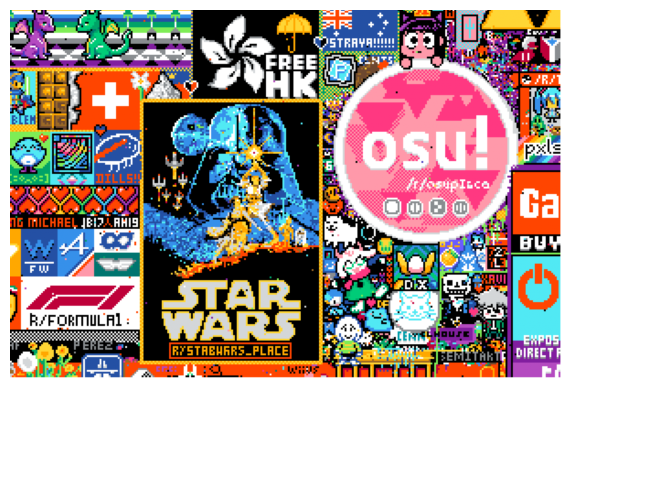

In [127]:
xmin, xmax = 500, 800
ymin, ymax = 650, 850

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 >= {xmin} AND x1 <= {xmax}) AND
        (y1 >= {ymin} AND y1 <= {ymax}) AND
        (timestamp < '2022-04-03 05:00:00')
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
createGif(xmin, xmax, ymin, ymax, df, start_date='2022-04-03 03:00:00', file="xqc_attack.gif")

## Expansion -> Bot Placements?

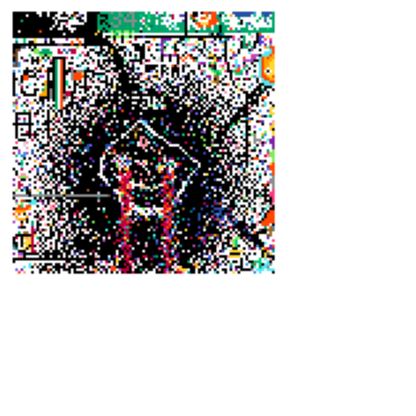

In [98]:
centerx = 1727
centery = 727
dr = 50

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 > {centerx - dr} AND x1 < {centerx + dr}) AND
        (y1 > {centery - dr} AND y1 < {centery + dr}) AND
        timestamp < CAST('2022-04-02 19:00:00 UTC' AS TIMESTAMP)
    ORDER BY
        timestamp ASC
"""
df = duckdb.query(query).df()

createGif(centerx - dr, centerx + dr, centery - dr, centery + dr, df, file="osu_expansion.gif")

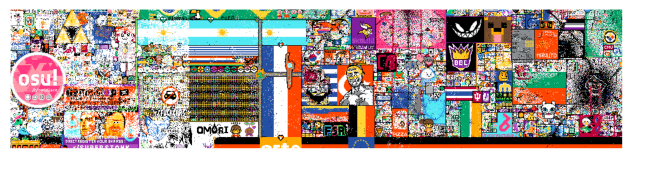

In [106]:
centerx1, centerx2 = 727, 1727
ymin, ymax = 600, 850
dr = 50

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 > {centerx1 - dr} AND x1 < {centerx2 + dr}) AND
        (y1 > {ymin} AND y1 < {ymax}) AND
        (timestamp > '2022-04-02 10:00:00' AND timestamp < '2022-04-02 19:00:00')
    ORDER BY
        timestamp ASC
"""
df = duckdb.query(query).df()

createGif(centerx1 - dr, centerx2 + dr, ymin, ymax, df, file="osu_og_expanded.gif")

## Whiteout = Bots?

C:\Users\Connor\AppData\Local\Temp\ipykernel_204480\1718351276.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anim["frame"] = (df_anim["timestamp_epoch"] // time_bin)


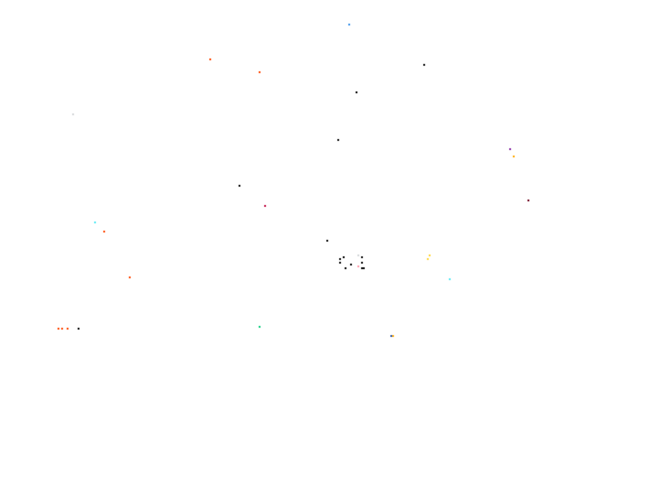

In [130]:
xmin, xmax = 500, 800
ymin, ymax = 650, 850

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 >= {xmin} AND x1 <= {xmax}) AND
        (y1 >= {ymin} AND y1 <= {ymax}) AND
        (timestamp < '2022-04-04 24:00:00')
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
createGif(xmin, xmax, ymin, ymax, df, start_date='2022-04-04 22:00:00', file="osu_whiteout.gif")

## Osu Honorable Mention 1 - Hit Circle

In [ ]:
xmin, xmax = 500, 800
ymin, ymax = 1650, 1850

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 >= {xmin} AND x1 <= {xmax}) AND
        (y1 >= {ymin} AND y1 <= {ymax}) AND
        (timestamp < '2022-04-04 24:00:00')
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
createGif(xmin, xmax, ymin, ymax, df, start_date='2022-04-04 22:00:00', file="osu_hit_circle.gif")

## Osu Honorable Mention 3 - WYSI 727

C:\Users\Connor\AppData\Local\Temp\ipykernel_204480\1718351276.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anim["frame"] = (df_anim["timestamp_epoch"] // time_bin)


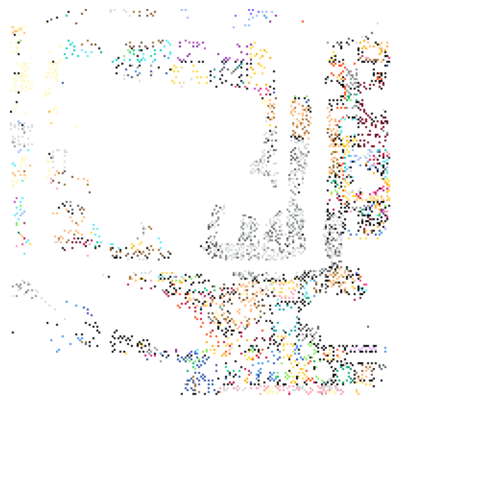

In [133]:
xmin, xmax = 1800, 2000
ymin, ymax = 1200, 1400

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        (x1 >= {xmin} AND x1 <= {xmax}) AND
        (y1 >= {ymin} AND y1 <= {ymax}) AND
        (timestamp < '2022-04-04 24:00:00')
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
createGif(xmin, xmax, ymin, ymax, df, start_date='2022-04-04 22:00:00', file="wysi_727.gif", fps=5)

# Void Movement

I didn't end up finishing this, but it was pretty interesting.

By plotting the most frequent pixels per region, defined as a 100x100 sqare, you can see the movement of the purple void throughout the canvas.

This also gives a pretty good indication of regions that were potentially botted.

In [70]:
def hex_to_rgb(h: str):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def createRegionMap(df: pd.DataFrame, bins: int = 100, 
                    file: str = None, fps: int = 10, dt: int = 50):
    if (not file):
        file = f"rplace_region_map.gif"
        
    # df['region_x'] = df['region'].apply(lambda r: r[0])
    # df['region_y'] = df['region'].apply(lambda r: r[1])

    width = df['region_x'].max() + 1
    height = df['region_y'].max() + 1

    canvas = np.ones((height, width, 3))

    df["rgb"] = df["pixel_color"].apply(hex_to_rgb)

    groups = list(df.groupby("timestamp_epoch"))

    fig, ax = plt.subplots()
    img = ax.imshow(canvas)
    ax.axis("off")

    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)

    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)

    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    title = ax.set_title("")

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.set_position([0, 0, 1, 1])

    def update(frame):
        timestamp, chunk = groups[frame]

        if (chunk.empty):
            return [img, title]
        
        for _, row in chunk.iterrows():
            x = row['region_x']
            y = row['region_y']
            canvas[y, x] = row['rgb']

        img.set_data(canvas)
        dt_str = pd.to_datetime(timestamp, unit="s").strftime("%Y-%m-%d %H:%M:%S")
        title.set_text(f"r/place regions - {dt_str}")

        return [img, title]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(groups),
        interval=dt,
        blit=False
    )

    fig.tight_layout(pad=2)
    ani.save(file, writer="pillow", fps=fps, savefig_kwargs={"pad_inches": 0.3})

In [46]:
REGION_SIZE = 100
query = f"""
    WITH
        regions AS (
            SELECT
                time_bucket(INTERVAL '5 minute', timestamp) AS t_bucket,
                pixel_color,
                x1, y1,
                x1 // {REGION_SIZE} AS region_x,
                y1 // {REGION_SIZE} AS region_y
            FROM
                '{PARQUET_PATH}'
        ),
        counts AS (
            SELECT
                t_bucket,
                pixel_color,
                region_x, region_y,
                COUNT(*) AS freq,
                ROW_NUMBER() OVER (PARTITION BY t_bucket, region_x, region_y ORDER BY COUNT(*) DESC) AS rnk
            FROM
                regions
            WHERE
                pixel_color NOT IN ('#FFFFFF', '#000000')
            GROUP BY
                t_bucket, pixel_color, region_x, region_y
        )
    SELECT
        EPOCH(t_bucket) AS timestamp_epoch,
        pixel_color,
        region_x, region_y
    FROM
        counts
    WHERE
        rnk = 1
    ORDER BY
        timestamp_epoch ASC
"""

df = duckdb.query(query).df()

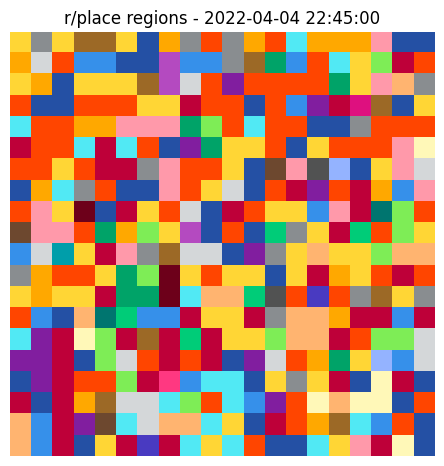

In [71]:
createRegionMap(df, fps=5)

# r/osuplace Logo Uptime

In [69]:
query = f"""
    WITH
        osu_region AS (
            SELECT 
                pixel_color,
                COUNT(*) AS freq,
                SUM(freq) OVER () AS total
            FROM 
                df
            WHERE
                region_x = 7 AND region_y = 7
            GROUP BY
                pixel_color
        )
    SELECT
        pixel_color,
        freq / total AS uptime
    FROM
        osu_region
    ORDER BY
        uptime DESC
"""

duckdb.query(query)

┌─────────────┬───────────────────────┐
│ pixel_color │        uptime         │
│   varchar   │        double         │
├─────────────┼───────────────────────┤
│ #FF99AA     │    0.9460285132382892 │
│ #811E9F     │  0.024439918533604887 │
│ #FF4500     │  0.016293279022403257 │
│ #FF3881     │  0.009164969450101833 │
│ #7EED56     │  0.003054989816700611 │
│ #DE107F     │ 0.0010183299389002036 │
└─────────────┴───────────────────────┘